In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, QTable, vstack
# import selection_utils
# import os
# # # Optional: prevent BLAS thread oversubscription when using multiple processes
# # os.environ.setdefault("OMP_NUM_THREADS", "1")
# # os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
# # os.environ.setdefault("MKL_NUM_THREADS", "1")
# # os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# from pathlib import Path
# from concurrent.futures import ProcessPoolExecutor
# import multiprocessing as mp

# import warnings
# warnings.filterwarnings('ignore')
# import random

from astropy.coordinates import SkyCoord
from astropy import units as u

import utils
from astropy.cosmology import default_cosmology
import selection_utils

import os
import sys
sys.path.insert(0, os.path.abspath('..'))
import scipy

In [2]:
cosmos = Table.read('/home/ir-band1/1-research/6-WST/COSMOS/COSMOS_11bands-SExtractor-Lephare.fits', format='fits')

In [3]:
cosmos = cosmos[(cosmos['u'] > 0) & (cosmos['g'] > 0) & (cosmos['r'] > 0) &
                (cosmos['i'] > 0) & (cosmos['z'] > 0) & (cosmos['y'] > 0) &
                (cosmos['J'] > 0) & (cosmos['H'] > 0)]

In [4]:
cosmos['gr'] = cosmos['g'] - cosmos['r']
cosmos['ri'] = cosmos['r'] - cosmos['i']
cosmos['rh'] = cosmos['r'] - cosmos['H']
cosmos['jh'] = cosmos['J'] - cosmos['H']
cosmos['ug'] = cosmos['u'] - cosmos['g']
cosmos['yh'] = cosmos['y'] - cosmos['H']
cosmos['rz'] = cosmos['r'] - cosmos['z']
cosmos['uz'] = cosmos['u'] - cosmos['z']
cosmos['gz'] = cosmos['g'] - cosmos['z']
    

In [5]:
hsc = Table.read('/home/ir-band1/1-research/6-WST/COSMOS/COSMOS-HSCpipe-Phosphoros.fits', format='fits')

In [6]:
gaia = Table.read('/home/ir-band1/1-research/6-WST/COSMOS/COSMOS_SExtractor_x_GAIA.fits', format='fits')

In [7]:
gaia = gaia[(gaia['g'] > 0) & (gaia['r'] > 0) & (gaia['i'] > 0) & (gaia['z'] > 0) & (gaia['y'] > 0) & (gaia['J'] > 0) & (gaia['H'] > 0)]

In [53]:
crs_qso = Table.read('/home/ir-band1/1-research/1-4MOST/1-Data/1-CRS/5-QSO/4most_qso_dr10_nomaskbit_v2_withmag.fits')

In [8]:
def compute_psf_minus_cmodel_i(data, band):
    mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
    mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
    return mag_psf - mag_cmodel

In [9]:
for b in ['g', 'r', 'i', 'z', 'y']:
    hsc[f'psf_minus_cmodel_{b}'] = compute_psf_minus_cmodel_i(hsc, b)

/tmp/ipykernel_237433/3669468170.py:2: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/3669468170.py:3: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/3669468170.py:3: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [10]:
# Cross-match cosmos_wise to hsc, then keep all hsc columns and add only non-overlapping cosmos_wise columns.

def _find_radec_cols(tab):
    ra_candidates = ['RA', 'ra', 'Ra']
    dec_candidates = ['DEC', 'dec', 'Dec']
    ra_col = next((c for c in ra_candidates if c in tab.colnames), None)
    dec_col = next((c for c in dec_candidates if c in tab.colnames), None)
    if ra_col is None or dec_col is None:
        raise KeyError("Could not find RA/DEC columns in one of the tables.")
    return ra_col, dec_col
max_sep = 1.0 * u.arcsec
cw_ra, cw_dec = _find_radec_cols(cosmos)
hsc_ra, hsc_dec = _find_radec_cols(hsc)

cw_coord = SkyCoord(cosmos[cw_ra], cosmos[cw_dec], unit='deg')
hsc_coord_local = SkyCoord(hsc[hsc_ra], hsc[hsc_dec], unit='deg')

idx, sep2d, _ = cw_coord.match_to_catalog_sky(hsc_coord_local)
keep = sep2d <= max_sep  # uses existing max_sep (1 arcsec)

hsc_matched = hsc[idx[keep]].copy()
cw_matched = cosmos[keep]

for colname in cw_matched.colnames:
    if colname not in hsc_matched.colnames:
        hsc_matched[colname] = cw_matched[colname]

crossmatched_hsc_cosmos = hsc_matched
crossmatched_hsc_cosmos

ID,RA,DEC,tract,patch,FLUX_APER_2_HSC-G,FLUXERR_APER_2_HSC-G,FLUX_APER_3_HSC-G,FLUXERR_APER_3_HSC-G,FLUX_PSF_HSC-G,FLUXERR_PSF_HSC-G,FLUX_KRON_HSC-G,FLUXERR_KRON_HSC-G,RADIUS_KRON_HSC-G,FLUX_CMODEL_HSC-G,FLUXERR_CMODEL_HSC-G,hasBadPhotometry_HSC-G,isDuplicated_HSC-G,isNoData_HSC-G,isSky_HSC-G,isParent_HSC-G,notObserved_HSC-G,isClean_HSC-G,FLUX_APER_2_HSC-I,FLUXERR_APER_2_HSC-I,FLUX_APER_3_HSC-I,FLUXERR_APER_3_HSC-I,FLUX_PSF_HSC-I,FLUXERR_PSF_HSC-I,FLUX_KRON_HSC-I,FLUXERR_KRON_HSC-I,RADIUS_KRON_HSC-I,FLUX_CMODEL_HSC-I,FLUXERR_CMODEL_HSC-I,hasBadPhotometry_HSC-I,isDuplicated_HSC-I,isNoData_HSC-I,isSky_HSC-I,isParent_HSC-I,notObserved_HSC-I,isClean_HSC-I,FLUX_APER_2_HSC-R,FLUXERR_APER_2_HSC-R,FLUX_APER_3_HSC-R,FLUXERR_APER_3_HSC-R,FLUX_PSF_HSC-R,FLUXERR_PSF_HSC-R,FLUX_KRON_HSC-R,FLUXERR_KRON_HSC-R,RADIUS_KRON_HSC-R,FLUX_CMODEL_HSC-R,FLUXERR_CMODEL_HSC-R,hasBadPhotometry_HSC-R,isDuplicated_HSC-R,isNoData_HSC-R,isSky_HSC-R,isParent_HSC-R,notObserved_HSC-R,isClean_HSC-R,FLUX_APER_2_HSC-Y,FLUXERR_APER_2_HSC-Y,FLUX_APER_3_HSC-Y,FLUXERR_APER_3_HSC-Y,FLUX_PSF_HSC-Y,FLUXERR_PSF_HSC-Y,FLUX_KRON_HSC-Y,FLUXERR_KRON_HSC-Y,RADIUS_KRON_HSC-Y,FLUX_CMODEL_HSC-Y,FLUXERR_CMODEL_HSC-Y,hasBadPhotometry_HSC-Y,isDuplicated_HSC-Y,isNoData_HSC-Y,isSky_HSC-Y,isParent_HSC-Y,notObserved_HSC-Y,isClean_HSC-Y,FLUX_APER_2_HSC-Z,FLUXERR_APER_2_HSC-Z,FLUX_APER_3_HSC-Z,FLUXERR_APER_3_HSC-Z,FLUX_PSF_HSC-Z,FLUXERR_PSF_HSC-Z,FLUX_KRON_HSC-Z,FLUXERR_KRON_HSC-Z,RADIUS_KRON_HSC-Z,FLUX_CMODEL_HSC-Z,FLUXERR_CMODEL_HSC-Z,hasBadPhotometry_HSC-Z,isDuplicated_HSC-Z,isNoData_HSC-Z,isSky_HSC-Z,isParent_HSC-Z,notObserved_HSC-Z,isClean_HSC-Z,FLUX_APER_2_MegaCam-u,FLUXERR_APER_2_MegaCam-u,FLUX_APER_3_MegaCam-u,FLUXERR_APER_3_MegaCam-u,FLUX_PSF_MegaCam-u,FLUXERR_PSF_MegaCam-u,FLUX_KRON_MegaCam-u,FLUXERR_KRON_MegaCam-u,RADIUS_KRON_MegaCam-u,FLUX_CMODEL_MegaCam-u,FLUXERR_CMODEL_MegaCam-u,hasBadPhotometry_MegaCam-u,isDuplicated_MegaCam-u,isNoData_MegaCam-u,isSky_MegaCam-u,isParent_MegaCam-u,notObserved_MegaCam-u,isClean_MegaCam-u,FLUX_APER_2_MegaCam-uS,FLUXERR_APER_2_MegaCam-uS,FLUX_APER_3_MegaCam-uS,FLUXERR_APER_3_MegaCam-uS,FLUX_PSF_MegaCam-uS,FLUXERR_PSF_MegaCam-uS,FLUX_KRON_MegaCam-uS,FLUXERR_KRON_MegaCam-uS,RADIUS_KRON_MegaCam-uS,FLUX_CMODEL_MegaCam-uS,FLUXERR_CMODEL_MegaCam-uS,hasBadPhotometry_MegaCam-uS,isDuplicated_MegaCam-uS,isNoData_MegaCam-uS,isSky_MegaCam-uS,isParent_MegaCam-uS,notObserved_MegaCam-uS,isClean_MegaCam-uS,FLUX_APER_2_VIRCAM-H,FLUXERR_APER_2_VIRCAM-H,FLUX_APER_3_VIRCAM-H,FLUXERR_APER_3_VIRCAM-H,FLUX_PSF_VIRCAM-H,FLUXERR_PSF_VIRCAM-H,FLUX_KRON_VIRCAM-H,FLUXERR_KRON_VIRCAM-H,RADIUS_KRON_VIRCAM-H,FLUX_CMODEL_VIRCAM-H,FLUXERR_CMODEL_VIRCAM-H,hasBadPhotometry_VIRCAM-H,isDuplicated_VIRCAM-H,isNoData_VIRCAM-H,isSky_VIRCAM-H,isParent_VIRCAM-H,notObserved_VIRCAM-H,isClean_VIRCAM-H,FLUX_APER_2_VIRCAM-J,FLUXERR_APER_2_VIRCAM-J,FLUX_APER_3_VIRCAM-J,FLUXERR_APER_3_VIRCAM-J,FLUX_PSF_VIRCAM-J,FLUXERR_PSF_VIRCAM-J,FLUX_KRON_VIRCAM-J,FLUXERR_KRON_VIRCAM-J,RADIUS_KRON_VIRCAM-J,FLUX_CMODEL_VIRCAM-J,FLUXERR_CMODEL_VIRCAM-J,hasBadPhotometry_VIRCAM-J,isDuplicated_VIRCAM-J,isNoData_VIRCAM-J,isSky_VIRCAM-J,isParent_VIRCAM-J,notObserved_VIRCAM-J,isClean_VIRCAM-J,FLUX_APER_2_VIRCAM-Ks,FLUXERR_APER_2_VIRCAM-Ks,FLUX_APER_3_VIRCAM-Ks,FLUXERR_APER_3_VIRCAM-Ks,FLUX_PSF_VIRCAM-Ks,FLUXERR_PSF_VIRCAM-Ks,FLUX_KRON_VIRCAM-Ks,FLUXERR_KRON_VIRCAM-Ks,RADIUS_KRON_VIRCAM-Ks,FLUX_CMODEL_VIRCAM-Ks,FLUXERR_CMODEL_VIRCAM-Ks,hasBadPhotometry_VIRCAM-Ks,isDuplicated_VIRCAM-Ks,isNoData_VIRCAM-Ks,isSky_VIRCAM-Ks,isParent_VIRCAM-Ks,notObserved_VIRCAM-Ks,isClean_VIRCAM-Ks,FLUX_APER_2_VIRCAM-Y,FLUXERR_APER_2_VIRCAM-Y,FLUX_APER_3_VIRCAM-Y,FLUXERR_APER_3_VIRCAM-Y,FLUX_PSF_VIRCAM-Y,FLUXERR_PSF_VIRCAM-Y,FLUX_KRON_VIRCAM-Y,FLUXERR_KRON_VIRCAM-Y,RADIUS_KRON_VIRCAM-Y,FLUX_CMODEL_VIRCAM-Y,FLUXERR_CMODEL_VIRCAM-Y,hasBadPhotometry_VIRCAM-Y,isDuplicated_VIRCAM-Y,isNoData_VIRCAM-Y,isSky_VIRCAM-Y,isParent_VIRCAM-Y,notObserved_VIRCAM-Y,isClean_VIRCAM-Y,isCompact,FLAG_FIELD_BINARY,isOutsideMask,isCompact_HSC-G,isCompact_HSC-R

In [54]:
# Cross-match cosmos_wise to hsc, then keep all hsc columns and add only non-overlapping cosmos_wise columns.

def _find_radec_cols(tab):
    ra_candidates = ['RA', 'ra', 'Ra']
    dec_candidates = ['DEC', 'dec', 'Dec']
    ra_col = next((c for c in ra_candidates if c in tab.colnames), None)
    dec_col = next((c for c in dec_candidates if c in tab.colnames), None)
    if ra_col is None or dec_col is None:
        raise KeyError("Could not find RA/DEC columns in one of the tables.")
    return ra_col, dec_col
max_sep = 1.0 * u.arcsec
cw_ra, cw_dec = _find_radec_cols(crs_qso)
hsc_ra, hsc_dec = _find_radec_cols(crossmatched_hsc_cosmos)

cw_coord = SkyCoord(crs_qso[cw_ra], crs_qso[cw_dec], unit='deg')
hsc_coord_local = SkyCoord(crossmatched_hsc_cosmos[hsc_ra], crossmatched_hsc_cosmos[hsc_dec], unit='deg')

idx, sep2d, _ = cw_coord.match_to_catalog_sky(hsc_coord_local)
keep = sep2d <= max_sep  # uses existing max_sep (1 arcsec)

hsc_matched = crossmatched_hsc_cosmos[idx[keep]].copy()
cw_matched = crs_qso[keep]

for colname in cw_matched.colnames:
    if colname not in hsc_matched.colnames:
        hsc_matched[colname] = cw_matched[colname]

crossmatched_hsc_crs = hsc_matched
crossmatched_hsc_crs

ID,RA,DEC,tract,patch,FLUX_APER_2_HSC-G,FLUXERR_APER_2_HSC-G,FLUX_APER_3_HSC-G,FLUXERR_APER_3_HSC-G,FLUX_PSF_HSC-G,FLUXERR_PSF_HSC-G,FLUX_KRON_HSC-G,FLUXERR_KRON_HSC-G,RADIUS_KRON_HSC-G,FLUX_CMODEL_HSC-G,FLUXERR_CMODEL_HSC-G,hasBadPhotometry_HSC-G,isDuplicated_HSC-G,isNoData_HSC-G,isSky_HSC-G,isParent_HSC-G,notObserved_HSC-G,isClean_HSC-G,FLUX_APER_2_HSC-I,FLUXERR_APER_2_HSC-I,FLUX_APER_3_HSC-I,FLUXERR_APER_3_HSC-I,FLUX_PSF_HSC-I,FLUXERR_PSF_HSC-I,FLUX_KRON_HSC-I,FLUXERR_KRON_HSC-I,RADIUS_KRON_HSC-I,FLUX_CMODEL_HSC-I,FLUXERR_CMODEL_HSC-I,hasBadPhotometry_HSC-I,isDuplicated_HSC-I,isNoData_HSC-I,isSky_HSC-I,isParent_HSC-I,notObserved_HSC-I,isClean_HSC-I,FLUX_APER_2_HSC-R,FLUXERR_APER_2_HSC-R,FLUX_APER_3_HSC-R,FLUXERR_APER_3_HSC-R,FLUX_PSF_HSC-R,FLUXERR_PSF_HSC-R,FLUX_KRON_HSC-R,FLUXERR_KRON_HSC-R,RADIUS_KRON_HSC-R,FLUX_CMODEL_HSC-R,FLUXERR_CMODEL_HSC-R,hasBadPhotometry_HSC-R,isDuplicated_HSC-R,isNoData_HSC-R,isSky_HSC-R,isParent_HSC-R,notObserved_HSC-R,isClean_HSC-R,FLUX_APER_2_HSC-Y,FLUXERR_APER_2_HSC-Y,FLUX_APER_3_HSC-Y,FLUXERR_APER_3_HSC-Y,FLUX_PSF_HSC-Y,FLUXERR_PSF_HSC-Y,FLUX_KRON_HSC-Y,FLUXERR_KRON_HSC-Y,RADIUS_KRON_HSC-Y,FLUX_CMODEL_HSC-Y,FLUXERR_CMODEL_HSC-Y,hasBadPhotometry_HSC-Y,isDuplicated_HSC-Y,isNoData_HSC-Y,isSky_HSC-Y,isParent_HSC-Y,notObserved_HSC-Y,isClean_HSC-Y,FLUX_APER_2_HSC-Z,FLUXERR_APER_2_HSC-Z,FLUX_APER_3_HSC-Z,FLUXERR_APER_3_HSC-Z,FLUX_PSF_HSC-Z,FLUXERR_PSF_HSC-Z,FLUX_KRON_HSC-Z,FLUXERR_KRON_HSC-Z,RADIUS_KRON_HSC-Z,FLUX_CMODEL_HSC-Z,FLUXERR_CMODEL_HSC-Z,hasBadPhotometry_HSC-Z,isDuplicated_HSC-Z,isNoData_HSC-Z,isSky_HSC-Z,isParent_HSC-Z,notObserved_HSC-Z,isClean_HSC-Z,FLUX_APER_2_MegaCam-u,FLUXERR_APER_2_MegaCam-u,FLUX_APER_3_MegaCam-u,FLUXERR_APER_3_MegaCam-u,FLUX_PSF_MegaCam-u,FLUXERR_PSF_MegaCam-u,FLUX_KRON_MegaCam-u,FLUXERR_KRON_MegaCam-u,RADIUS_KRON_MegaCam-u,FLUX_CMODEL_MegaCam-u,FLUXERR_CMODEL_MegaCam-u,hasBadPhotometry_MegaCam-u,isDuplicated_MegaCam-u,isNoData_MegaCam-u,isSky_MegaCam-u,isParent_MegaCam-u,notObserved_MegaCam-u,isClean_MegaCam-u,FLUX_APER_2_MegaCam-uS,FLUXERR_APER_2_MegaCam-uS,FLUX_APER_3_MegaCam-uS,FLUXERR_APER_3_MegaCam-uS,FLUX_PSF_MegaCam-uS,FLUXERR_PSF_MegaCam-uS,FLUX_KRON_MegaCam-uS,FLUXERR_KRON_MegaCam-uS,RADIUS_KRON_MegaCam-uS,FLUX_CMODEL_MegaCam-uS,FLUXERR_CMODEL_MegaCam-uS,hasBadPhotometry_MegaCam-uS,isDuplicated_MegaCam-uS,isNoData_MegaCam-uS,isSky_MegaCam-uS,isParent_MegaCam-uS,notObserved_MegaCam-uS,isClean_MegaCam-uS,FLUX_APER_2_VIRCAM-H,FLUXERR_APER_2_VIRCAM-H,FLUX_APER_3_VIRCAM-H,FLUXERR_APER_3_VIRCAM-H,FLUX_PSF_VIRCAM-H,FLUXERR_PSF_VIRCAM-H,FLUX_KRON_VIRCAM-H,FLUXERR_KRON_VIRCAM-H,RADIUS_KRON_VIRCAM-H,FLUX_CMODEL_VIRCAM-H,FLUXERR_CMODEL_VIRCAM-H,hasBadPhotometry_VIRCAM-H,isDuplicated_VIRCAM-H,isNoData_VIRCAM-H,isSky_VIRCAM-H,isParent_VIRCAM-H,notObserved_VIRCAM-H,isClean_VIRCAM-H,FLUX_APER_2_VIRCAM-J,FLUXERR_APER_2_VIRCAM-J,FLUX_APER_3_VIRCAM-J,FLUXERR_APER_3_VIRCAM-J,FLUX_PSF_VIRCAM-J,FLUXERR_PSF_VIRCAM-J,FLUX_KRON_VIRCAM-J,FLUXERR_KRON_VIRCAM-J,RADIUS_KRON_VIRCAM-J,FLUX_CMODEL_VIRCAM-J,FLUXERR_CMODEL_VIRCAM-J,hasBadPhotometry_VIRCAM-J,isDuplicated_VIRCAM-J,isNoData_VIRCAM-J,isSky_VIRCAM-J,isParent_VIRCAM-J,notObserved_VIRCAM-J,isClean_VIRCAM-J,FLUX_APER_2_VIRCAM-Ks,FLUXERR_APER_2_VIRCAM-Ks,FLUX_APER_3_VIRCAM-Ks,FLUXERR_APER_3_VIRCAM-Ks,FLUX_PSF_VIRCAM-Ks,FLUXERR_PSF_VIRCAM-Ks,FLUX_KRON_VIRCAM-Ks,FLUXERR_KRON_VIRCAM-Ks,RADIUS_KRON_VIRCAM-Ks,FLUX_CMODEL_VIRCAM-Ks,FLUXERR_CMODEL_VIRCAM-Ks,hasBadPhotometry_VIRCAM-Ks,isDuplicated_VIRCAM-Ks,isNoData_VIRCAM-Ks,isSky_VIRCAM-Ks,isParent_VIRCAM-Ks,notObserved_VIRCAM-Ks,isClean_VIRCAM-Ks,FLUX_APER_2_VIRCAM-Y,FLUXERR_APER_2_VIRCAM-Y,FLUX_APER_3_VIRCAM-Y,FLUXERR_APER_3_VIRCAM-Y,FLUX_PSF_VIRCAM-Y,FLUXERR_PSF_VIRCAM-Y,FLUX_KRON_VIRCAM-Y,FLUXERR_KRON_VIRCAM-Y,RADIUS_KRON_VIRCAM-Y,FLUX_CMODEL_VIRCAM-Y,FLUXERR_CMODEL_VIRCAM-Y,hasBadPhotometry_VIRCAM-Y,isDuplicated_VIRCAM-Y,isNoData_VIRCAM-Y,isSky_VIRCAM-Y,isParent_VIRCAM-Y,notObserved_VIRCAM-Y,isClean_VIRCAM-Y,isCompact,FLAG_FIELD_BINARY,isOutsideMask,isCompact_HSC-G,isCompact_HSC-R

In [11]:
# Cross-match cosmos_wise to hsc, then keep all hsc columns and add only non-overlapping cosmos_wise columns.

def _find_radec_cols(tab):
    ra_candidates = ['RA', 'ra', 'Ra']
    dec_candidates = ['DEC', 'dec', 'Dec']
    ra_col = next((c for c in ra_candidates if c in tab.colnames), None)
    dec_col = next((c for c in dec_candidates if c in tab.colnames), None)
    if ra_col is None or dec_col is None:
        raise KeyError("Could not find RA/DEC columns in one of the tables.")
    return ra_col, dec_col
max_sep = 1.0 * u.arcsec
cw_ra, cw_dec = _find_radec_cols(crossmatched_hsc_cosmos)
hsc_ra, hsc_dec = _find_radec_cols(gaia)

cw_coord = SkyCoord(crossmatched_hsc_cosmos[cw_ra], crossmatched_hsc_cosmos[cw_dec], unit='deg')
hsc_coord_local = SkyCoord(gaia[hsc_ra], gaia[hsc_dec], unit='deg')

idx, sep2d, _ = cw_coord.match_to_catalog_sky(hsc_coord_local)
keep = sep2d <= max_sep  # uses existing max_sep (1 arcsec)

hsc_matched = gaia[idx[keep]].copy()
cw_matched = crossmatched_hsc_cosmos[keep]

for colname in cw_matched.colnames:
    if colname not in hsc_matched.colnames:
        hsc_matched[colname] = cw_matched[colname]

crossmatched_hsc_gaia = hsc_matched
crossmatched_hsc_gaia

ID,RA,DEC,TRACT,PATCH,MASK,FLAG_FIELD,A_WORLD,B_WORLD,KRON_RADIUS,THETA_WORLD,ELONGATION,ELLIPTICITY,EB_V,FWHM_WORLD_HSC_I,MU_MAX_HSC_I,CLASS_STAR_HSC_I,FLUX_RADIUS_0.25_HSC_I,FLUX_RADIUS_0.5_HSC_I,FLUX_RADIUS_0.75_HSC_I,FUV,NUV,u,uS,g,r,i,z,y,Yv,J,H,Ks,FUV_err,NUV_err,u_err,uS_err,g_err,r_err,i_err,z_err,y_err,Yv_err,J_err,H_err,Ks_err,MAG_APER_2s_u,MAG_APER_2s_uS,MAG_APER_2s_g,MAG_APER_2s_r,MAG_APER_2s_i,MAG_APER_2s_z,MAG_APER_2s_y,MAG_APER_2s_Yv,MAG_APER_2s_J,MAG_APER_2s_H,MAG_APER_2s_Ks,MAGERR_APER_2s_u,MAGERR_APER_2s_uS,MAGERR_APER_2s_g,MAGERR_APER_2s_r,MAGERR_APER_2s_i,MAGERR_APER_2s_z,MAGERR_APER_2s_y,MAGERR_APER_2s_Yv,MAGERR_APER_2s_J,MAGERR_APER_2s_H,MAGERR_APER_2s_Ks,MAG_APER_3s_u,MAG_APER_3s_uS,MAG_APER_3s_g,MAG_APER_3s_r,MAG_APER_3s_i,MAG_APER_3s_z,MAG_APER_3s_y,MAG_APER_3s_Yv,MAG_APER_3s_J,MAG_APER_3s_H,MAG_APER_3s_Ks,MAGERR_APER_3s_u,MAGERR_APER_3s_uS,MAGERR_APER_3s_g,MAGERR_APER_3s_r,MAGERR_APER_3s_i,MAGERR_APER_3s_z,MAGERR_APER_3s_y,MAGERR_APER_3s_Yv,MAGERR_APER_3s_J,MAGERR_APER_3s_H,MAGERR_APER_3s_Ks,OFFSET_MAG_2s,OFFSET_MAG_3s,CONTEXT,MAG_ABS_FUV,MAG_ABS_NUV,MAG_ABS_u,MAG_ABS_uS,MAG_ABS_g,MAG_ABS_r,MAG_ABS_i,MAG_ABS_z,MAG_ABS_y,MAG_ABS_Yv,MAG_ABS_J,MAG_ABS_H,MAG_ABS_Ks,Z_BEST,Z_BEST68_LOW,Z_BEST68_HIGH,CHI_BEST,CHI_STAR,CHI_QSO,MOD_BEST,MOD_STAR,MOD_QSO,Z_ML,Z_ML68_LOW,Z_ML68_HIGH,Z_SEC,Z_QSO,Z_BC03,ZPHOT,MOD_BEST_BC03,AGE_BEST,EBV_BEST,EXTLAW_BEST,AGE_MED,MASS_MED,MASS_BEST,MASS_INF,MASS_SUP,SFR_MED,SFR_BEST,SFR_INF,SFR_SUP,SSFR_MED,SSFR_BEST,SSFR_INF,SSFR_SUP,LUM_NUV_BEST,LUM_R_BEST,LUM_K_BEST,OBJ_TYPE,COMPACT,STAR_FORMING,ST_TRAIL,CLEAN,FLAG_FIELD_BINARY,designation,parallax,parallax_error,pmra,pmdec,pmdec_error,parallax_over_error,pmra_error,phot_g_mean_mag,GroupID,GroupSize,Separation,tract,patch,FLUX_APER_2_HSC-G,FLUXERR_APER_2_HSC-G,FLUX_APER_3_HSC-G,FLUXERR_APER_3_HSC-G,FLUX_PSF_HSC-G,FLUXERR_PSF_HSC-G,FLUX_KRON_HSC-G,FLUXERR_KRON_HSC-G,RADIUS_KRON_HSC-G,FLUX_CMODEL_HSC-G,FLUXERR_CMODEL_HSC-G,hasBadPhotometry_HSC-G,isDuplicated_HSC-G,isNoData_HSC-G,isSky_HSC-G,isParent_HSC-G,notObserved_HSC-G,isClean_HSC-G,FLUX_APER_2_HSC-I,FLUXERR_APER_2_HSC-I,FLUX_APER_3_HSC-I,FLUXERR_APER_3_HSC-I,FLUX_PSF_HSC-I,FLUXERR_PSF_HSC-I,FLUX_KRON_HSC-I,FLUXERR_KRON_HSC-I,RADIUS_KRON_HSC-I,FLUX_CMODEL_HSC-I,FLUXERR_CMODEL_HSC-I,hasBadPhotometry_HSC-I,isDuplicated_HSC-I,isNoData_HSC-I,isSky_HSC-I,isParent_HSC-I,notObserved_HSC-I,isClean_HSC-I,FLUX_APER_2_HSC-R,FLUXERR_APER_2_HSC-R,FLUX_APER_3_HSC-R,FLUXERR_APER_3_HSC-R,FLUX_PSF_HSC-R,FLUXERR_PSF_HSC-R,FLUX_KRON_HSC-R,FLUXERR_KRON_HSC-R,RADIUS_KRON_HSC-R,FLUX_CMODEL_HSC-R,FLUXERR_CMODEL_HSC-R,hasBadPhotometry_HSC-R,isDuplicated_HSC-R,isNoData_HSC-R,isSky_HSC-R,isParent_HSC-R,notObserved_HSC-R,isClean_HSC-R,FLUX_APER_2_HSC-Y,FLUXERR_APER_2_HSC-Y,FLUX_APER_3_HSC-Y,FLUXERR_APER_3_HSC-Y,FLUX_PSF_HSC-Y,FLUXERR_PSF_HSC-Y,FLUX_KRON_HSC-Y,FLUXERR_KRON_HSC-Y,RADIUS_KRON_HSC-Y,FLUX_CMODEL_HSC-Y,FLUXERR_CMODEL_HSC-Y,hasBadPhotometry_HSC-Y,isDuplicated_HSC-Y,isNoData_HSC-Y,isSky_HSC-Y,isParent_HSC-Y,notObserved_HSC-Y,isClean_HSC-Y,FLUX_APER_2_HSC-Z,FLUXERR_APER_2_HSC-Z,FLUX_APER_3_HSC-Z,FLUXERR_APER_3_HSC-Z,FLUX_PSF_HSC-Z,FLUXERR_PSF_HSC-Z,FLUX_KRON_HSC-Z,FLUXERR_KRON_HSC-Z,RADIUS_KRON_HSC-Z,FLUX_CMODEL_HSC-Z,FLUXERR_CMODEL_HSC-Z,hasBadPhotometry_HSC-Z,isDuplicated_HSC-Z,isNoData_HSC-Z,isSky_HSC-Z,isParent_HSC-Z,notObserved_HSC-Z,isClean_HSC-Z,FLUX_APER_2_MegaCam-u,FLUXERR_APER_2_MegaCam-u,FLUX_APER_3_MegaCam-u,FLUXERR_APER_3_MegaCam-u,FLUX_PSF_MegaCam-u,FLUXERR_PSF_MegaCam-u,FLUX_KRON_MegaCam-u,FLUXERR_KRON_MegaCam-u,RADIUS_KRON_MegaCam-u,FLUX_CMODEL_MegaCam-u,FLUXERR_CMODEL_MegaCam-u,hasBadPhotometry_MegaCam-u,isDuplicated_MegaCam-u,isNoData_MegaCam-u,isSky_MegaCam-u,isParent_MegaCam-u,notObserved_MegaCam-u,isClean_MegaCam-u,FLUX_APER_2_MegaCam-uS,FLUXERR_APER_2_MegaCam-uS,FLUX_APER_3_MegaCam-uS,FLUXERR_APER_3_MegaCam-uS,FLUX_PSF_MegaCam-uS,FLUXERR_PSF_MegaCam-uS,FLUX_KRON_MegaCam-uS,FLUXERR_KRON_MegaCam-uS,RADIUS_KRON_MegaCam-uS,FLUX_CMODEL_MegaCam-uS,FLUXERR_CMODEL_MegaCam-uS,hasBadP

In [12]:
stars = crossmatched_hsc_gaia[crossmatched_hsc_gaia['parallax'] > 0]

In [34]:
def compute_psf_minus_cmodel_i(data, band= 'i'):
    # Compute PSF - CModel magnitude for a given band as a point source selection criterion
    
    mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
    mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
    return mag_psf - mag_cmodel

In [14]:
def psf_cut(cat, band='i', limit=0.1, mag_limit=24.5, mag_col='i'):
    # Apply a PSF - CModel magnitude cut to select point sources (potential quasars) in the HSC catalog

    psf_minus_cmodel = compute_psf_minus_cmodel_i(cat, band=band)
    mag_cut = cat[mag_col] < mag_limit
    psf_cut = psf_minus_cmodel < limit
    return psf_cut


In [84]:
def wst_target_selection_with_psf_with_h(data, mag_limit=24.5, band='g'):
    # This function applies a magnitude cut, color cuts, and a PSF - CModel magnitude cut to select quasar candidates from the HSC catalog, incorporating the H-band for improved colour selection.

    # Apply magnitude cut
    mag_sel = data[band] < mag_limit
    
    # Define selection criteria based on the plots
    gr = data['g'] - data['r']
    rh = data['r'] - data['H']
    psf_minus_cmodel_i = compute_psf_minus_cmodel_i(data, band='i')
    # Example criteria based on the observed distributions (these can be refined)
    colour_cut_1 = gr < 1.18
    colour_cut_2 = rh > 1.5 * gr - 0.4

    psf_cut = np.abs(psf_minus_cmodel_i) < 0.1

    # Combine with magnitude selection
    final_sel = mag_sel & colour_cut_1 & colour_cut_2 & psf_cut
    
    return final_sel

In [16]:
def wst_target_selection_with_psf_noh(data, mag_limit=24.5):
    # This function applies a magnitude cut, color cuts, and a PSF - CModel magnitude cut to select quasar candidates from the HSC catalog without using the H-band for colour selection.

    mag_sel = data['g'] < mag_limit

    gr = data['g'] - data['r']
    rz = data['r'] - data['z']
    uz = data['u'] - data['z']
    psf_minus_cmodel_i = compute_psf_minus_cmodel_i(data, band='i')

    colour_cut_1 = gr < 1.18

    # remove the two diagonal stripes in the r-z vs u-z plane
    stripe_1 = (uz > 1.0) & (uz < 4.3) & ((rz > 0.20 * uz - 0.03))
    stripe_2 = (uz > 4.3) & ((rz > uz - 3.50) | (rz < 0.7 * uz - 2.4))
    stripe_3 = (uz < 1.0) & (uz>-1)
    stripes = stripe_1 | stripe_2 | stripe_3
    psf_cut = np.abs(psf_minus_cmodel_i) < 0.1
    sel1 = mag_sel & colour_cut_1 & psf_cut
    final_sel = sel1 & stripes
    return final_sel

In [ ]:
def wst_target_selection_noh_zcut(data, mag_limit=24.5):
    # This function applies a magnitude cut, color cuts, and a PSF - CModel magnitude cut to select quasar candidates from the HSC catalog without using the H-band for colour selection.

    mag_sel = data['z'] < mag_limit

    gr = data['g'] - data['r']
    rz = data['r'] - data['z']
    uz = data['u'] - data['z']
    psf_minus_cmodel_i = compute_psf_minus_cmodel_i(data, band='i')

    colour_cut_1 = gr < 1.18

    # remove the two diagonal stripes in the r-z vs u-z plane
    stripe_1 = (uz > 1.0) & (uz < 4.3) & ((rz > 0.20 * uz - 0.03))
    stripe_2 = (uz > 4.3) & ((rz > uz - 3.50) | (rz < 0.7 * uz - 2.4))
    stripe_3 = (uz < 1.0) & (uz>-1)
    stripes = stripe_1 | stripe_2 | stripe_3
    psf_cut = np.abs(psf_minus_cmodel_i) < 0.1
    sel1 = mag_sel & colour_cut_1 & psf_cut
    final_sel = sel1 & stripes
    return final_sel

In [69]:
def wst_target_selection_no_h_WDrejection(data, mag_limit=24.5, band='g'):
    """
    WST QSO candidate selection without Euclid H-band.

    Applies a g-band magnitude limit, a broad red-locus cut, an HSC i-band
    point-source morphology cut, a stellar-locus rejection in (u-z, r-z),
    and a white-dwarf rejection in (u-g, r-i).

    Parameters
    ----------
    data : structured array or DataFrame
        Catalogue with LSST/HSC u, g, r, i, z magnitudes and HSC PSF/CModel
        fluxes in i.
    mag_limit : float
        g-band magnitude limit (default 24.5).

    Returns
    -------
    ndarray of bool
        True for selected QSO candidates.
    """

    # --- Magnitude limit -------------------------------------------------
    mag_sel = data[band] < mag_limit

    # --- Broad red-locus cut --------------------------------------------
    gr = data['g'] - data['r']
    colour_cut_1 = gr < 1.18

    # --- Point-source morphology (HSC i-band PSF - CModel) ---------------
    psf_minus_cmodel_i = compute_psf_minus_cmodel_i(data, band='i')
    psf_cut = np.abs(psf_minus_cmodel_i) < 0.1

    # --- Stellar-locus rejection in (u-z, r-z) ---------------------------
    # Retention regions: keep objects falling OUTSIDE the stellar locus
    # traced by Gaia-parallax stars.
    uz = data['u'] - data['z']
    rz = data['r'] - data['z']

    region_1 = (uz < 4.3) & (rz > 0.20 * uz - 0.03)
    # region_2 = (uz > 4.3) & ((rz > uz - 3.50) | (rz < 0.7 * uz - 2.4))
    region_2 = (uz > 4.3) & (rz > uz - 3.50)
    # region_3 = (uz < 1.0) & (uz > -1.0)
    stellar_locus_pass = region_1 | region_2 

    # --- White-dwarf rejection in (u-g, r-i) -----------------------------
    # WDs occupy the blue corner: hot blackbody SEDs produce u-g << 0
    # while r-i remains near zero (Rayleigh-Jeans tail). QSOs have
    # u-g >~ 0 at z < 2.2, so the WD corner is well-separated from the
    # QSO locus.
    ug = data['u'] - data['g']
    ri = data['r'] - data['i']
    wd_corner = (ug < -0.1) & (ri < 0.3)
    wd_pass = ~wd_corner

    # --- Combine ---------------------------------------------------------
    final_sel = mag_sel & colour_cut_1 & psf_cut & stellar_locus_pass & wd_pass

    return final_sel

In [70]:
wst_sel_noh = wst_target_selection_with_psf_noh(crossmatched_hsc_cosmos, mag_limit=24.5)

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [71]:
wst_sel_noh.sum()/3.566

np.float64(1752.383623107123)

In [72]:
wst_sel_noh_WDrejected = wst_target_selection_no_h_WDrejection(crossmatched_hsc_cosmos, mag_limit=24.5, band='z')

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [73]:
wst_sel_noh_WDrejected.sum()/3.566

np.float64(5588.895120583287)

In [74]:
wst_sel_noh_WDrejected_zcut = wst_target_selection_no_h_WDrejection(crossmatched_hsc_cosmos, mag_limit=24.5, band='z')

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [75]:
wst_sel_noh_WDrejected_zcut.sum()/3.566

np.float64(5588.895120583287)

In [79]:
wst_sel_noh_WDrejected_gcut = wst_target_selection_no_h_WDrejection(crossmatched_hsc_cosmos, mag_limit=24.5, band='g')

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [85]:
wst_sel_with_h_gcut = wst_target_selection_with_psf_with_h(crossmatched_hsc_cosmos, mag_limit=24.5, band='g')

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [86]:
wst_sel_with_h_gcut.sum()/3.566

np.float64(1594.7840717891195)

In [91]:
wst_sel_with_h_zcut = wst_target_selection_with_psf_with_h(crossmatched_hsc_cosmos, mag_limit=24.5, band='z')

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [ ]:
for band in ['u', 'g', 'r', 'i', 'z']:
    wst_sel_with_h_bandcut = wst_target_selection_with_psf_with_h(crossmatched_hsc_cosmos, mag_limit=24.5, band=band)
    print(f"WST selection with H and {band}-band cut: {wst_sel_with_h_bandcut.sum()} candidates, {wst_sel_with_h_bandcut.sum()/3.566:.2f} per deg^2")

WST selection with H and u-band cut: 3566 candidates, 1000.00 per deg^2
WST selection with H and g-band cut: 5687 candidates, 1594.78 per deg^2
WST selection with H and r-band cut: 9020 candidates, 2529.44 per deg^2
WST selection with H and i-band cut: 14285 candidates, 4005.89 per deg^2
WST selection with H and z-band cut: 19753 candidates, 5539.26 per deg^2


/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [95]:
for band in ['u', 'g', 'r', 'i', 'z']:
    wst_sel_no_h_bandcut = wst_target_selection_no_h_WDrejection(crossmatched_hsc_cosmos, mag_limit=24.5, band=band)
    print(f"WST selection No H and {band}-band cut: {wst_sel_no_h_bandcut.sum()} candidates, {wst_sel_no_h_bandcut.sum()/3.566:.2f} per deg^2")

WST selection No H and u-band cut: 3448 candidates, 966.91 per deg^2
WST selection No H and g-band cut: 5234 candidates, 1467.75 per deg^2
WST selection No H and r-band cut: 8935 candidates, 2505.61 per deg^2
WST selection No H and i-band cut: 14449 candidates, 4051.88 per deg^2
WST selection No H and z-band cut: 19930 candidates, 5588.90 per deg^2


/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [92]:
wst_sel_with_h_zcut.sum()/3.566

np.float64(5539.259674705552)

In [81]:
wst_sel_psf = wst_target_selection_with_psf_with_h(crossmatched_hsc_cosmos, mag_limit=24.5)

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [77]:
wst_sel_z = wst_target_selection_noh_zcut(crossmatched_hsc_cosmos, mag_limit=24.5)

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [78]:
wst_sel_z.sum()/3.566

np.float64(6132.641615255188)

In [19]:
wst_sel_with_h = wst_target_selection_with_psf_with_h(crossmatched_hsc_cosmos, mag_limit=24.5)

/tmp/ipykernel_237433/72402566.py:4: RuntimeWarning: invalid value encountered in log10
  mag_psf = 27.0 - 2.5 * np.log10(data[f'FLUX_PSF_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: divide by zero encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])
/tmp/ipykernel_237433/72402566.py:5: RuntimeWarning: invalid value encountered in log10
  mag_cmodel = 27.0 - 2.5 * np.log10(data[f'FLUX_CMODEL_HSC-{band.upper()}'])


In [44]:
wst_sel_with_h.sum()/3.566

np.float64(1594.7840717891195)

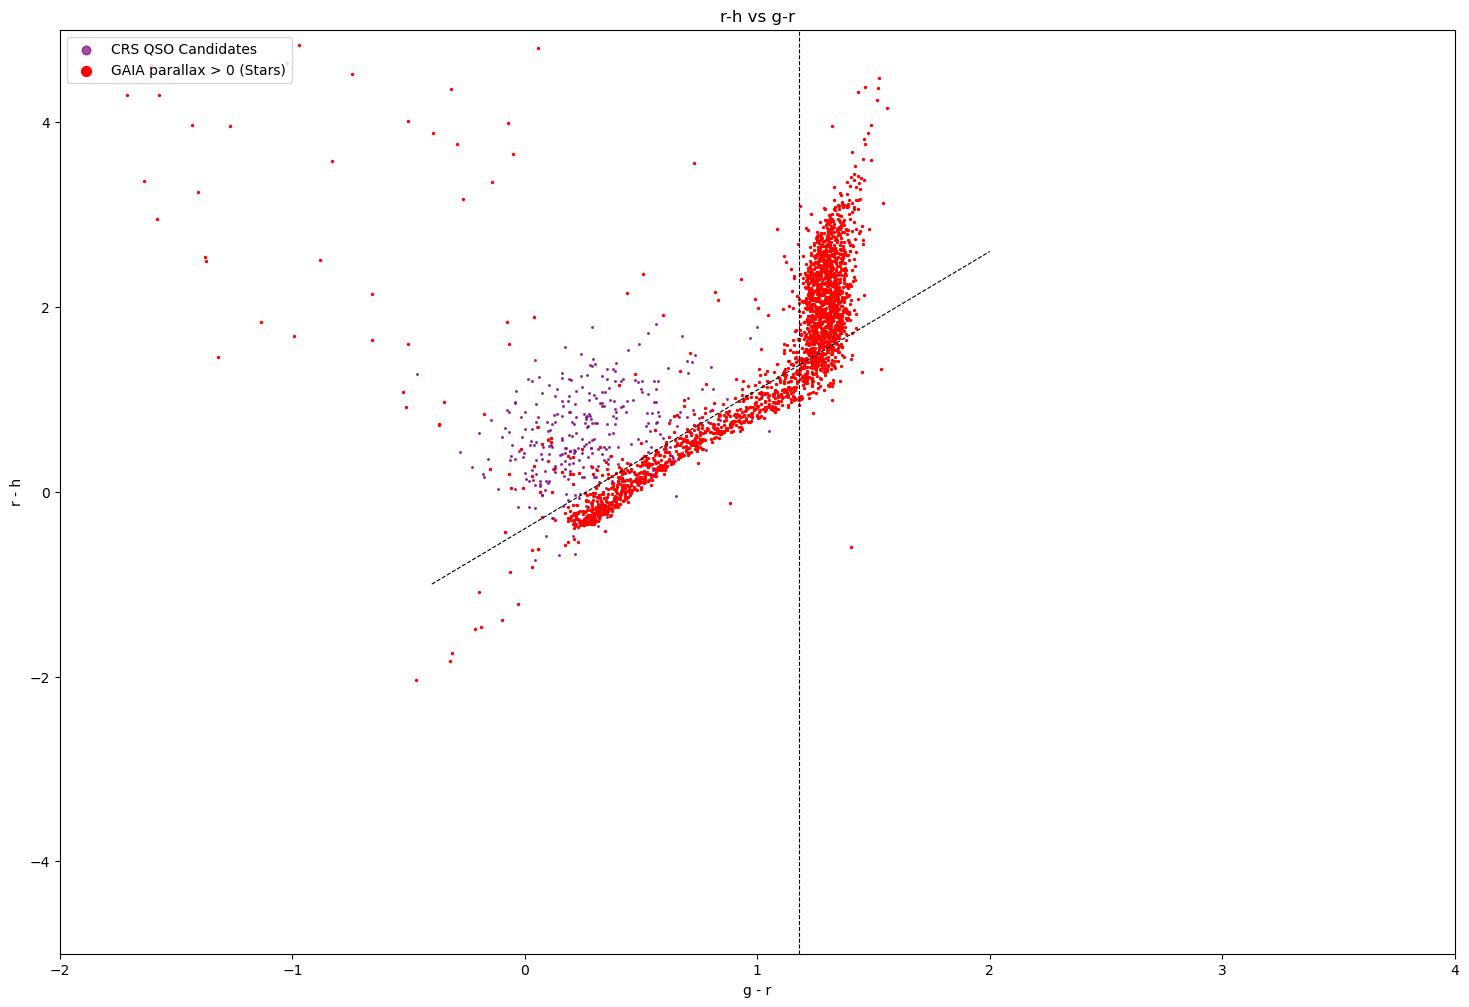

In [96]:
fig, axes = plt.subplots(1, 1, figsize=(18, 12), sharex=False)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
axes =  [axes]

xline = np.array([-0.4, 2], dtype=float)
yline_1 = 1.5 * xline - 0.4

xline_2 = np.array([1, 3], dtype=float)
yline_2 = 1 * xline_2 - 3.55

# axes[0].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh_WDrejected_zcut], crossmatched_hsc_cosmos['rh'][wst_sel_noh_WDrejected_zcut], s=1, alpha=0.7, color='magenta', label='WST Z cut WD-rejected')
# axes[0].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh_WDrejected_gcut], crossmatched_hsc_cosmos['rh'][wst_sel_noh_WDrejected_gcut], s=1, alpha=0.7, color='cyan', label='WST G cut WD-rejected')
axes[0].scatter(crossmatched_hsc_crs['gr'], crossmatched_hsc_crs['rh'], s=1.5, alpha=0.7, color='purple', label='CRS QSO Candidates')
axes[0].scatter(stars['gr'], stars['rh'],  s=2, alpha=1, color='red', label='GAIA parallax > 0 (Stars)')

axes[0].plot(xline, yline_1, color='black', linestyle='--', lw=0.8)
# axes[0].plot(xline_2, yline_2, color='black', linestyle='--', lw=0.8)

axes[0].set_xlabel('g - r')
axes[0].set_ylabel('r - h')
axes[0].set_title('r-h vs g-r')
axes[0].axvline(x=1.18, color='black', linestyle='--', lw=0.8)
axes[0].set_xlim(-2, 4)
axes[0].set_ylim(-5, 5)
axes[0].legend(loc='upper left', markerscale=5)
plt.show()

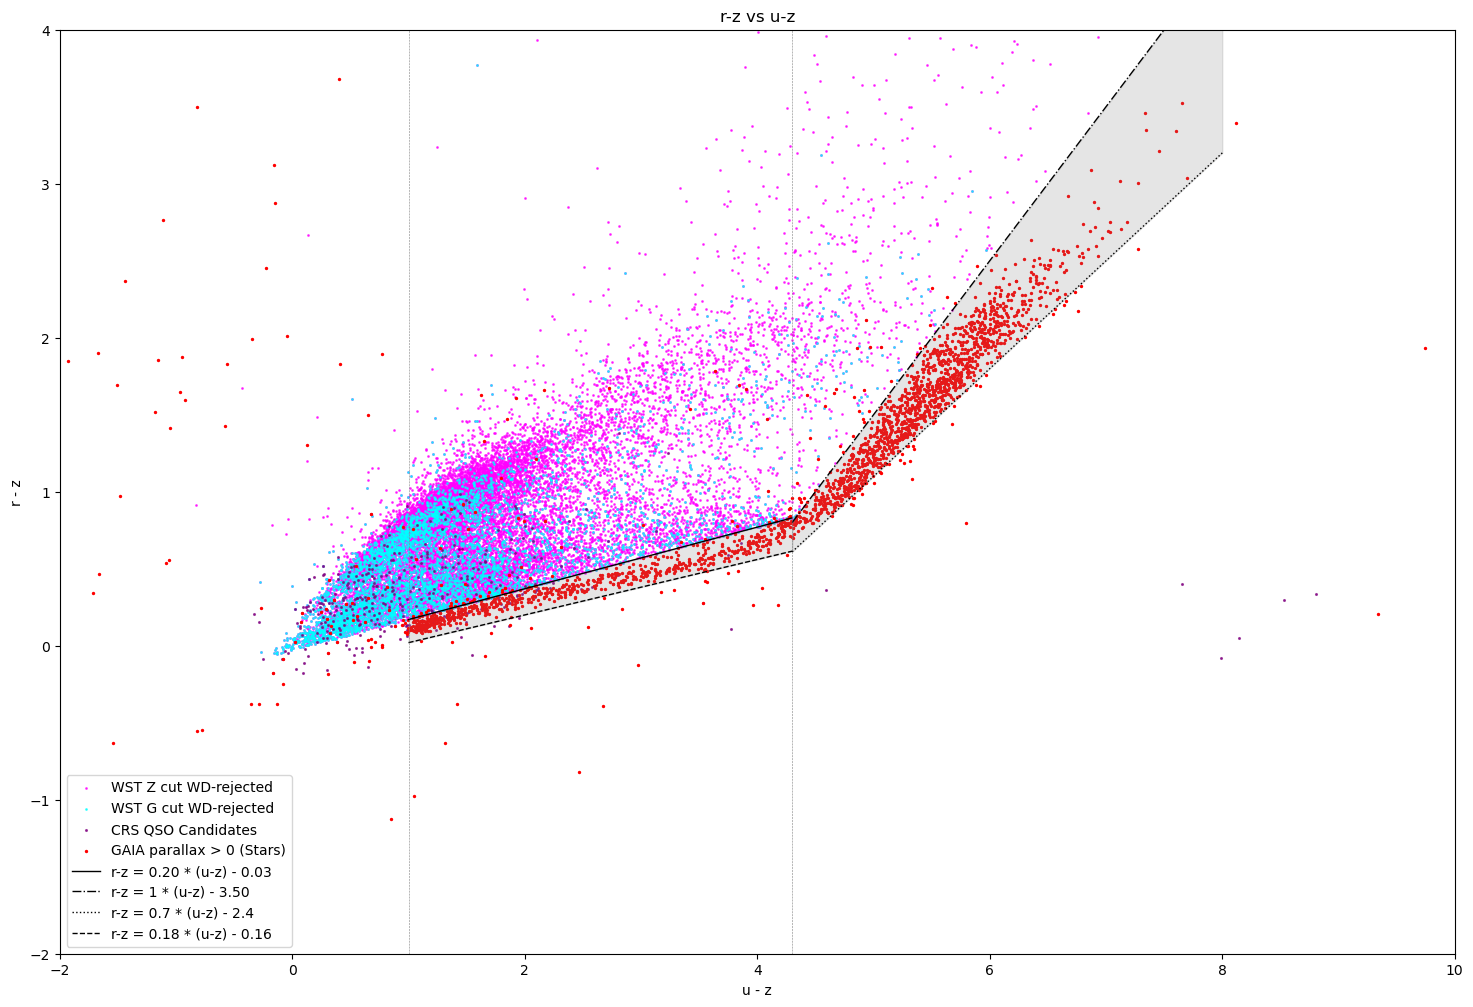

In [82]:
fig, axes = plt.subplots(1, 1, figsize=(18, 12), sharex=False)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
axes =  [axes]

xline = np.array([1, 4.3], dtype=float)
yline_1 = 0.20 * xline - 0.03

xline_2 = np.array([4.3, 8], dtype=float)
yline_2 = 1 * xline_2 - 3.50

xline_3 = np.array([4.3, 8], dtype=float)
yline_3 = 0.7 * xline_3 - 2.4

xline_4 = np.array([1, 4.3], dtype=float)
yline_4 = 0.18 * xline_4 - 0.16

# axes[0].scatter(crossmatched_hsc_cosmos['uz'], crossmatched_hsc_cosmos['rz'], s=1, color='lightgray', label='All Sources')
# axes[0].scatter(crossmatched_hsc_cosmos['uz'][wst_sel], crossmatched_hsc_cosmos['rz'][wst_sel], s=1, alpha=0.7, color='green', label='WST Selected')
# axes[0].scatter(crossmatched_hsc_cosmos['uz'][wst_sel_psf], crossmatched_hsc_cosmos['rz'][wst_sel_psf], s=1, alpha=0.7, color='blue', label='WST With H')
axes[0].scatter(crossmatched_hsc_cosmos['uz'][wst_sel_noh_WDrejected_zcut], crossmatched_hsc_cosmos['rz'][wst_sel_noh_WDrejected_zcut], s=1, alpha=0.7, color='magenta', label='WST Z cut WD-rejected')
axes[0].scatter(crossmatched_hsc_cosmos['uz'][wst_sel_noh_WDrejected_gcut], crossmatched_hsc_cosmos['rz'][wst_sel_noh_WDrejected_gcut], s=1, alpha=0.7, color='cyan', label='WST G cut WD-rejected')
axes[0].scatter(crossmatched_hsc_crs['uz'], crossmatched_hsc_crs['rz'], s=1.5, alpha=0.7, color='purple', label='CRS QSO Candidates')
axes[0].scatter(stars['uz'], stars['rz'],  s=2, alpha=1, color='red', label='GAIA parallax > 0 (Stars)')
# axes[0].scatter(crossmatched_hsc_cosmos_wise['uz'][qso_wise], crossmatched_hsc_cosmos_wise['rz'][qso_wise], s=1.5, alpha=0.2, color='blue', label='QSO Candidates')
axes[0].plot(xline, yline_1, color='black', linestyle='-', lw=1, label=f'r-z = 0.20 * (u-z) - 0.03')
axes[0].plot(xline_2, yline_2, color='black', linestyle='-.', lw=1, label=f'r-z = 1 * (u-z) - 3.50')
axes[0].plot(xline_3, yline_3, color='black', linestyle=':', lw=1, label=f'r-z = 0.7 * (u-z) - 2.4')
axes[0].plot(xline_4, yline_4, color='black', linestyle='--', lw=1, label=f'r-z = 0.18 * (u-z) - 0.16')

axes[0].fill_between(
    xline,
    yline_1,
    yline_4,
    where=(yline_1 >= yline_4),
    color='gray',
    alpha=0.2,
    interpolate=True,
)

axes[0].fill_between(
    xline_2,
    yline_2,
    yline_3,
    where=(yline_2 >= yline_3),
    color='gray',
    alpha=0.2,
    interpolate=True,
)

axes[0].set_xlabel('u - z')
axes[0].set_ylabel('r - z')
axes[0].set_title('r-z vs u-z')
axes[0].axvline(x=4.3, color='grey', linestyle='--', lw=0.4)
axes[0].axvline(x=1, color='grey', linestyle='--', lw=0.4)

axes[0].set_xlim(-2, 10)
axes[0].set_ylim(-2, 4)

plt.legend()
plt.show()

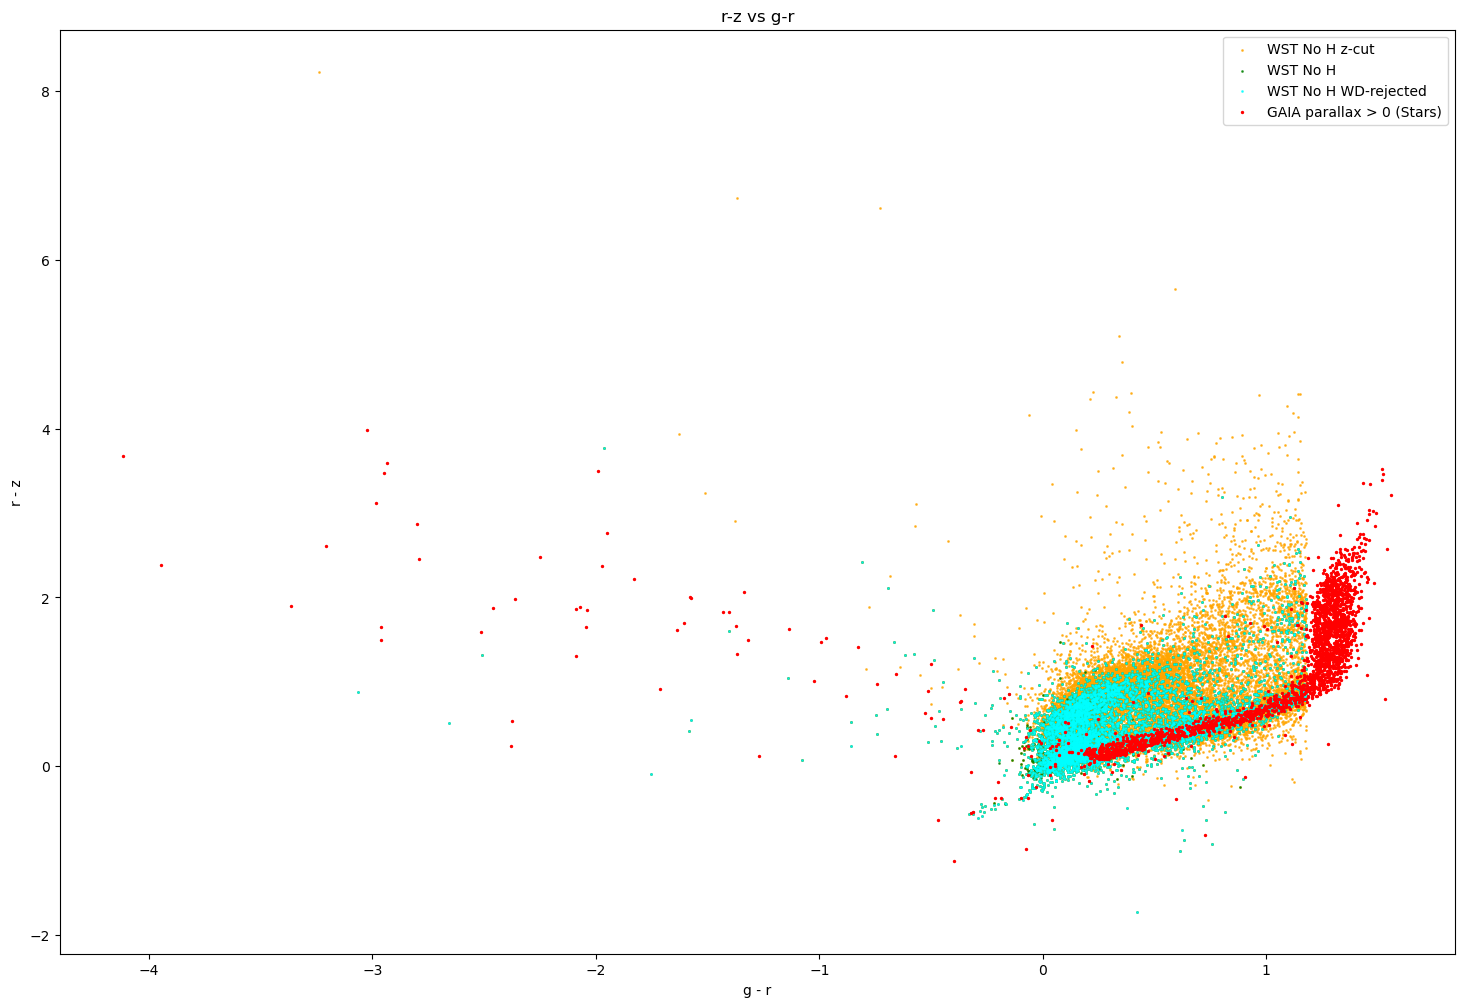

In [52]:
fig, axes = plt.subplots(1, 1, figsize=(18, 12), sharex=False)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
axes =  [axes]

xline = np.array([1, 4.3], dtype=float)
yline_1 = 0.20 * xline - 0.03

xline_2 = np.array([4.3, 8], dtype=float)
yline_2 = 1 * xline_2 - 3.50

xline_3 = np.array([4.3, 8], dtype=float)
yline_3 = 0.7 * xline_3 - 2.4

xline_4 = np.array([1, 4.3], dtype=float)
yline_4 = 0.18 * xline_4 - 0.16

# axes[0].scatter(crossmatched_hsc_cosmos['uz'], crossmatched_hsc_cosmos['rz'], s=1, color='lightgray', label='All Sources')
# axes[0].scatter(crossmatched_hsc_cosmos['uz'][wst_sel], crossmatched_hsc_cosmos['rz'][wst_sel], s=1, alpha=0.7, color='green', label='WST Selected')
# axes[0].scatter(crossmatched_hsc_cosmos['uz'][wst_sel_psf], crossmatched_hsc_cosmos['rz'][wst_sel_psf], s=1, alpha=0.7, color='blue', label='WST With H')
axes[0].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_z], crossmatched_hsc_cosmos['rz'][wst_sel_z], s=1, alpha=0.7, color='orange', label='WST No H z-cut')
axes[0].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh], crossmatched_hsc_cosmos['rz'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[0].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh_WDrejected], crossmatched_hsc_cosmos['rz'][wst_sel_noh_WDrejected], s=1, alpha=0.7, color='cyan', label='WST No H WD-rejected')

axes[0].scatter(stars['gr'], stars['rz'],  s=2, alpha=1, color='red', label='GAIA parallax > 0 (Stars)')
# axes[0].scatter(crossmatched_hsc_cosmos_wise['uz'][qso_wise], crossmatched_hsc_cosmos_wise['rz'][qso_wise], s=1.5, alpha=0.2, color='blue', label='QSO Candidates')
# axes[0].plot(xline, yline_1, color='black', linestyle='-', lw=1, label=f'r-z = 0.20 * (u-z) - 0.03')
# axes[0].plot(xline_2, yline_2, color='black', linestyle='-.', lw=1, label=f'r-z = 1 * (u-z) - 3.50')
# axes[0].plot(xline_3, yline_3, color='black', linestyle=':', lw=1, label=f'r-z = 0.7 * (u-z) - 2.4')
# axes[0].plot(xline_4, yline_4, color='black', linestyle='--', lw=1, label=f'r-z = 0.18 * (u-z) - 0.16')

# axes[0].fill_between(
#     xline,
#     yline_1,
#     yline_4,
#     where=(yline_1 >= yline_4),
#     color='gray',
#     alpha=0.2,
#     interpolate=True,
# )

# axes[0].fill_between(
#     xline_2,
#     yline_2,
#     yline_3,
#     where=(yline_2 >= yline_3),
#     color='gray',
#     alpha=0.2,
#     interpolate=True,
# )

axes[0].set_xlabel('g - r')
axes[0].set_ylabel('r - z')
axes[0].set_title('r-z vs g-r')
# axes[0].axvline(x=4.3, color='grey', linestyle='--', lw=0.4)
# axes[0].axvline(x=1, color='grey', linestyle='--', lw=0.4)

axes[0].set_xlim(-2, 10)
axes[0].set_ylim(-2, 4)

plt.legend()
plt.show()

In [22]:
crossmatched_hsc_cosmos

ID,RA,DEC,tract,patch,FLUX_APER_2_HSC-G,FLUXERR_APER_2_HSC-G,FLUX_APER_3_HSC-G,FLUXERR_APER_3_HSC-G,FLUX_PSF_HSC-G,FLUXERR_PSF_HSC-G,FLUX_KRON_HSC-G,FLUXERR_KRON_HSC-G,RADIUS_KRON_HSC-G,FLUX_CMODEL_HSC-G,FLUXERR_CMODEL_HSC-G,hasBadPhotometry_HSC-G,isDuplicated_HSC-G,isNoData_HSC-G,isSky_HSC-G,isParent_HSC-G,notObserved_HSC-G,isClean_HSC-G,FLUX_APER_2_HSC-I,FLUXERR_APER_2_HSC-I,FLUX_APER_3_HSC-I,FLUXERR_APER_3_HSC-I,FLUX_PSF_HSC-I,FLUXERR_PSF_HSC-I,FLUX_KRON_HSC-I,FLUXERR_KRON_HSC-I,RADIUS_KRON_HSC-I,FLUX_CMODEL_HSC-I,FLUXERR_CMODEL_HSC-I,hasBadPhotometry_HSC-I,isDuplicated_HSC-I,isNoData_HSC-I,isSky_HSC-I,isParent_HSC-I,notObserved_HSC-I,isClean_HSC-I,FLUX_APER_2_HSC-R,FLUXERR_APER_2_HSC-R,FLUX_APER_3_HSC-R,FLUXERR_APER_3_HSC-R,FLUX_PSF_HSC-R,FLUXERR_PSF_HSC-R,FLUX_KRON_HSC-R,FLUXERR_KRON_HSC-R,RADIUS_KRON_HSC-R,FLUX_CMODEL_HSC-R,FLUXERR_CMODEL_HSC-R,hasBadPhotometry_HSC-R,isDuplicated_HSC-R,isNoData_HSC-R,isSky_HSC-R,isParent_HSC-R,notObserved_HSC-R,isClean_HSC-R,FLUX_APER_2_HSC-Y,FLUXERR_APER_2_HSC-Y,FLUX_APER_3_HSC-Y,FLUXERR_APER_3_HSC-Y,FLUX_PSF_HSC-Y,FLUXERR_PSF_HSC-Y,FLUX_KRON_HSC-Y,FLUXERR_KRON_HSC-Y,RADIUS_KRON_HSC-Y,FLUX_CMODEL_HSC-Y,FLUXERR_CMODEL_HSC-Y,hasBadPhotometry_HSC-Y,isDuplicated_HSC-Y,isNoData_HSC-Y,isSky_HSC-Y,isParent_HSC-Y,notObserved_HSC-Y,isClean_HSC-Y,FLUX_APER_2_HSC-Z,FLUXERR_APER_2_HSC-Z,FLUX_APER_3_HSC-Z,FLUXERR_APER_3_HSC-Z,FLUX_PSF_HSC-Z,FLUXERR_PSF_HSC-Z,FLUX_KRON_HSC-Z,FLUXERR_KRON_HSC-Z,RADIUS_KRON_HSC-Z,FLUX_CMODEL_HSC-Z,FLUXERR_CMODEL_HSC-Z,hasBadPhotometry_HSC-Z,isDuplicated_HSC-Z,isNoData_HSC-Z,isSky_HSC-Z,isParent_HSC-Z,notObserved_HSC-Z,isClean_HSC-Z,FLUX_APER_2_MegaCam-u,FLUXERR_APER_2_MegaCam-u,FLUX_APER_3_MegaCam-u,FLUXERR_APER_3_MegaCam-u,FLUX_PSF_MegaCam-u,FLUXERR_PSF_MegaCam-u,FLUX_KRON_MegaCam-u,FLUXERR_KRON_MegaCam-u,RADIUS_KRON_MegaCam-u,FLUX_CMODEL_MegaCam-u,FLUXERR_CMODEL_MegaCam-u,hasBadPhotometry_MegaCam-u,isDuplicated_MegaCam-u,isNoData_MegaCam-u,isSky_MegaCam-u,isParent_MegaCam-u,notObserved_MegaCam-u,isClean_MegaCam-u,FLUX_APER_2_MegaCam-uS,FLUXERR_APER_2_MegaCam-uS,FLUX_APER_3_MegaCam-uS,FLUXERR_APER_3_MegaCam-uS,FLUX_PSF_MegaCam-uS,FLUXERR_PSF_MegaCam-uS,FLUX_KRON_MegaCam-uS,FLUXERR_KRON_MegaCam-uS,RADIUS_KRON_MegaCam-uS,FLUX_CMODEL_MegaCam-uS,FLUXERR_CMODEL_MegaCam-uS,hasBadPhotometry_MegaCam-uS,isDuplicated_MegaCam-uS,isNoData_MegaCam-uS,isSky_MegaCam-uS,isParent_MegaCam-uS,notObserved_MegaCam-uS,isClean_MegaCam-uS,FLUX_APER_2_VIRCAM-H,FLUXERR_APER_2_VIRCAM-H,FLUX_APER_3_VIRCAM-H,FLUXERR_APER_3_VIRCAM-H,FLUX_PSF_VIRCAM-H,FLUXERR_PSF_VIRCAM-H,FLUX_KRON_VIRCAM-H,FLUXERR_KRON_VIRCAM-H,RADIUS_KRON_VIRCAM-H,FLUX_CMODEL_VIRCAM-H,FLUXERR_CMODEL_VIRCAM-H,hasBadPhotometry_VIRCAM-H,isDuplicated_VIRCAM-H,isNoData_VIRCAM-H,isSky_VIRCAM-H,isParent_VIRCAM-H,notObserved_VIRCAM-H,isClean_VIRCAM-H,FLUX_APER_2_VIRCAM-J,FLUXERR_APER_2_VIRCAM-J,FLUX_APER_3_VIRCAM-J,FLUXERR_APER_3_VIRCAM-J,FLUX_PSF_VIRCAM-J,FLUXERR_PSF_VIRCAM-J,FLUX_KRON_VIRCAM-J,FLUXERR_KRON_VIRCAM-J,RADIUS_KRON_VIRCAM-J,FLUX_CMODEL_VIRCAM-J,FLUXERR_CMODEL_VIRCAM-J,hasBadPhotometry_VIRCAM-J,isDuplicated_VIRCAM-J,isNoData_VIRCAM-J,isSky_VIRCAM-J,isParent_VIRCAM-J,notObserved_VIRCAM-J,isClean_VIRCAM-J,FLUX_APER_2_VIRCAM-Ks,FLUXERR_APER_2_VIRCAM-Ks,FLUX_APER_3_VIRCAM-Ks,FLUXERR_APER_3_VIRCAM-Ks,FLUX_PSF_VIRCAM-Ks,FLUXERR_PSF_VIRCAM-Ks,FLUX_KRON_VIRCAM-Ks,FLUXERR_KRON_VIRCAM-Ks,RADIUS_KRON_VIRCAM-Ks,FLUX_CMODEL_VIRCAM-Ks,FLUXERR_CMODEL_VIRCAM-Ks,hasBadPhotometry_VIRCAM-Ks,isDuplicated_VIRCAM-Ks,isNoData_VIRCAM-Ks,isSky_VIRCAM-Ks,isParent_VIRCAM-Ks,notObserved_VIRCAM-Ks,isClean_VIRCAM-Ks,FLUX_APER_2_VIRCAM-Y,FLUXERR_APER_2_VIRCAM-Y,FLUX_APER_3_VIRCAM-Y,FLUXERR_APER_3_VIRCAM-Y,FLUX_PSF_VIRCAM-Y,FLUXERR_PSF_VIRCAM-Y,FLUX_KRON_VIRCAM-Y,FLUXERR_KRON_VIRCAM-Y,RADIUS_KRON_VIRCAM-Y,FLUX_CMODEL_VIRCAM-Y,FLUXERR_CMODEL_VIRCAM-Y,hasBadPhotometry_VIRCAM-Y,isDuplicated_VIRCAM-Y,isNoData_VIRCAM-Y,isSky_VIRCAM-Y,isParent_VIRCAM-Y,notObserved_VIRCAM-Y,isClean_VIRCAM-Y,isCompact,FLAG_FIELD_BINARY,isOutsideMask,isCompact_HSC-G,isCompact_HSC-R

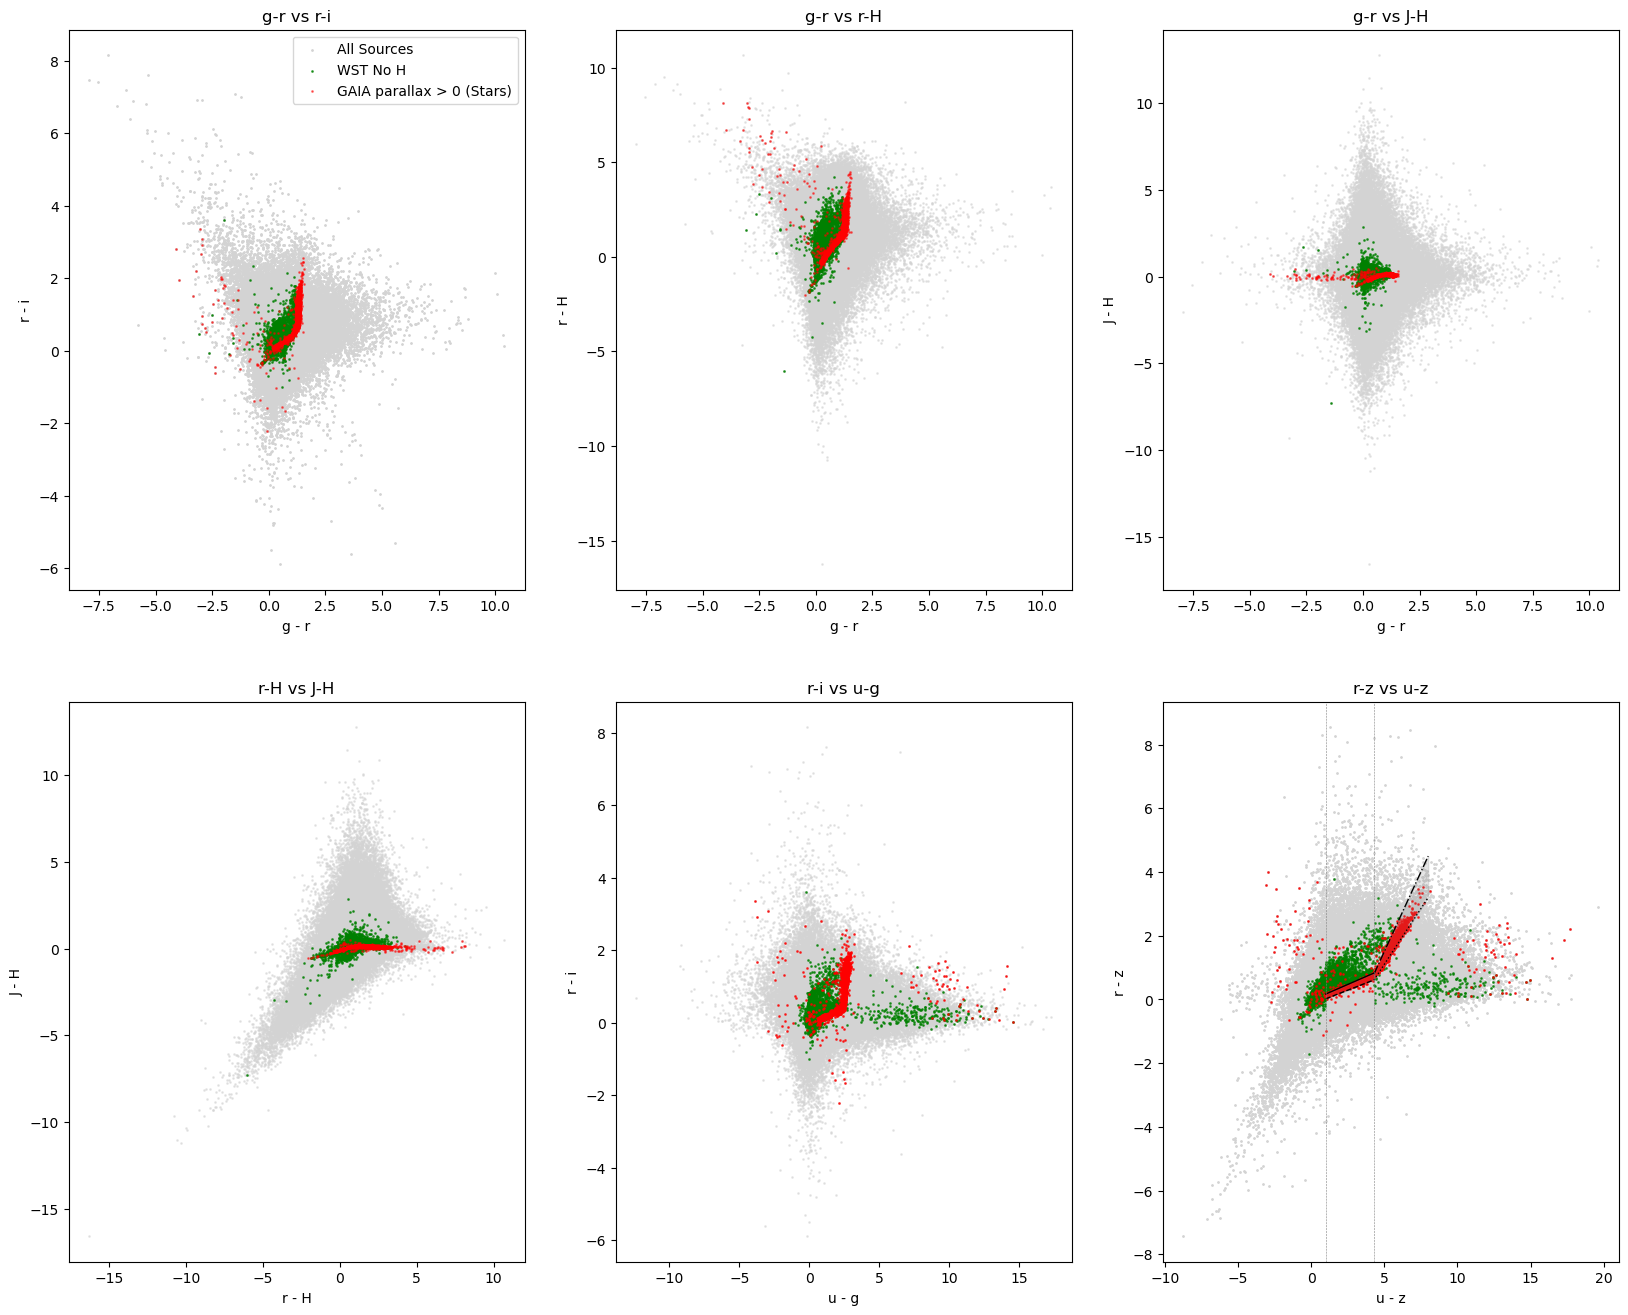

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(20, 16), sharex=False)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
axes = axes.flatten() if len(axes.shape) > 1 else [axes]

axes[0].scatter(crossmatched_hsc_cosmos['gr'], crossmatched_hsc_cosmos['ri'], s=1, color='lightgray', label='All Sources')
axes[0].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh], crossmatched_hsc_cosmos['ri'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[0].scatter(stars['gr'], stars['ri'], s=1, alpha=0.5, color='red', label='GAIA parallax > 0 (Stars)')

# axes[0].set_xlim(-0.5, 2.2)
axes[0].set_xlabel('g - r')
axes[0].set_ylabel('r - i')
axes[0].set_title('g-r vs r-i')
axes[0].legend()

axes[1].scatter(crossmatched_hsc_cosmos['gr'], crossmatched_hsc_cosmos['rh'], s=1, alpha=0.5, color='lightgray', label='All Sources')
axes[1].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh], crossmatched_hsc_cosmos['rh'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[1].scatter(stars['gr'], stars['rh'], s=1, alpha=0.5, color='red', label='GAIA parallax > 0 (Stars)')

# axes[1].set_xlim(-0.5, 2.2)

axes[1].set_xlabel('g - r')
axes[1].set_ylabel('r - H')
axes[1].set_title('g-r vs r-H')
# axes[1].legend()

axes[2].scatter(crossmatched_hsc_cosmos['gr'], crossmatched_hsc_cosmos['jh'], s=1, alpha=0.5, color='lightgray', label='All Sources')
axes[2].scatter(crossmatched_hsc_cosmos['gr'][wst_sel_noh], crossmatched_hsc_cosmos['jh'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[2].scatter(stars['gr'], stars['jh'], s=1, alpha=0.5, color='red', label='GAIA parallax > 0 (Stars)')

# axes[2].set_xlim(-0.5, 2.2)

axes[2].set_xlabel('g - r')
axes[2].set_ylabel('J - H')
axes[2].set_title('g-r vs J-H')
# axes[2].legend()

axes[3].scatter(crossmatched_hsc_cosmos['rh'], crossmatched_hsc_cosmos['jh'], s=1, alpha=0.5, color='lightgray', label='All Sources')
axes[3].scatter(crossmatched_hsc_cosmos['rh'][wst_sel_noh], crossmatched_hsc_cosmos['jh'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[3].scatter(stars['rh'], stars['jh'], s=1, alpha=0.5, color='red', label='GAIA parallax > 0 (Stars)')

# axes[3].set_xlim(-1, 5)
# axes[3].set_ylim(-0.5, 1)

axes[3].set_xlabel('r - H')
axes[3].set_ylabel('J - H')
axes[3].set_title('r-H vs J-H')

axes[4].scatter(crossmatched_hsc_cosmos['ug'], crossmatched_hsc_cosmos['ri'],  s=1, alpha=0.5, color='lightgray', label='All Sources')
axes[4].scatter(crossmatched_hsc_cosmos['ug'][wst_sel_noh], crossmatched_hsc_cosmos['ri'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[4].scatter(stars['ug'], stars['ri'],  s=1, alpha=0.7, color='red', label='GAIA parallax > 0 (Stars)')

axes[4].set_xlabel('u - g')
axes[4].set_ylabel('r - i')
axes[4].set_title('r-i vs u-g')

xline = np.array([-0.4, 5], dtype=float)
yline_1 = 0.25 * xline - 0.05

axes[5].scatter(crossmatched_hsc_cosmos['uz'], crossmatched_hsc_cosmos['rz'], s=1, color='lightgray', label='All Sources')
axes[5].scatter(crossmatched_hsc_cosmos['uz'][wst_sel_noh], crossmatched_hsc_cosmos['rz'][wst_sel_noh], s=1, alpha=0.7, color='green', label='WST No H')
axes[5].scatter(stars['uz'], stars['rz'],  s=1, alpha=0.7, color='red', label='GAIA parallax > 0 (Stars)')
# axes[5].plot(xline, yline_1, color='black', linestyle='--', lw=0.8)

xline = np.array([1, 4.3], dtype=float)
yline_1 = 0.20 * xline - 0.03

xline_2 = np.array([4.3, 8], dtype=float)
yline_2 = 1 * xline_2 - 3.50

xline_3 = np.array([4.3, 8], dtype=float)
yline_3 = 0.7 * xline_3 - 2.4

xline_4 = np.array([1, 4.3], dtype=float)
yline_4 = 0.18 * xline_4 - 0.16

axes[5].fill_between(
    xline,
    yline_1,
    yline_4,
    where=(yline_1 >= yline_4),
    color='gray',
    alpha=0.2,
    interpolate=True,
)

axes[5].fill_between(
    xline_2,
    yline_2,
    yline_3,
    where=(yline_2 >= yline_3),
    color='gray',
    alpha=0.2,
    interpolate=True,
)
axes[5].plot(xline, yline_1, color='black', linestyle='-', lw=1, label=f'r-z = 0.20 * (u-z) - 0.03')
axes[5].plot(xline_2, yline_2, color='black', linestyle='-.', lw=1, label=f'r-z = 1 * (u-z) - 3.50')
axes[5].plot(xline_3, yline_3, color='black', linestyle=':', lw=1, label=f'r-z = 0.7 * (u-z) - 2.4')
axes[5].plot(xline_4, yline_4, color='black', linestyle='--', lw=1, label=f'r-z = 0.18 * (u-z) - 0.16')

axes[5].axvline(x=4.3, color='grey', linestyle='--', lw=0.4)
axes[5].axvline(x=1, color='grey', linestyle='--', lw=0.4)

axes[5].set_xlabel('u - z')
axes[5].set_ylabel('r - z')
axes[5].set_title('r-z vs u-z')

plt.show()


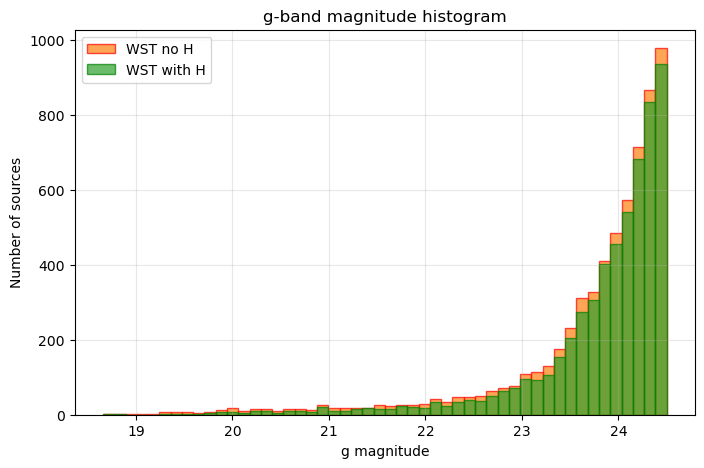

In [25]:
g = crossmatched_hsc_cosmos['g']
# mask = (g > 0) & np.isfinite(g)

plt.figure(figsize=(8,5))
# plt.hist(g, bins=50, color='C0', edgecolor='k', alpha=0.7, label='All Sources', density=True)
plt.hist(g[wst_sel_noh], bins=50, color='C1', edgecolor='r', alpha=0.7, label='WST no H', density=False)
plt.hist(g[wst_sel_with_h], bins=50, color='C2', edgecolor='g', alpha=0.7, label='WST with H', density=False)
plt.xlabel('g magnitude')
plt.ylabel('Number of sources')
plt.title('g-band magnitude histogram')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

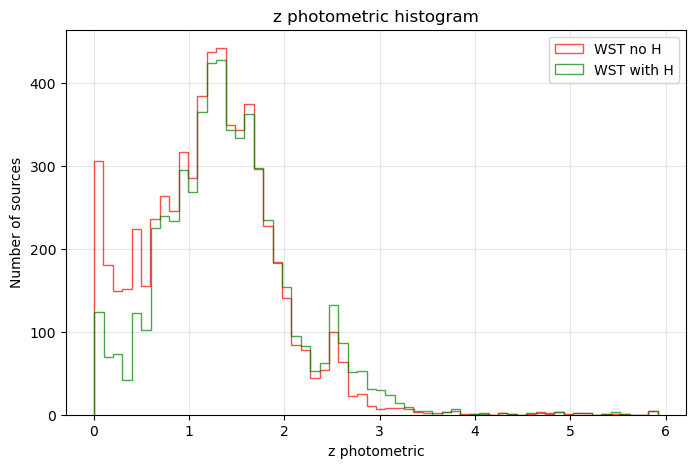

In [106]:
z_photo = crossmatched_hsc_cosmos['ZPHOT_NIR']
# mask = (g > 0) & np.isfinite(g)

plt.figure(figsize=(8,5))
# plt.hist(g, bins=50, color='C0', edgecolor='k', alpha=0.7, label='All Sources', density=True)
plt.hist(z_photo[wst_sel_noh], bins=60, color='C1', edgecolor='r', alpha=0.7, label='WST no H', density=False, histtype='step')
plt.hist(z_photo[wst_sel_with_h], bins=60, color='C2', edgecolor='g', alpha=0.7, label='WST with H', density=False, histtype='step')
plt.xlabel('z photometric')
plt.ylabel('Number of sources')
plt.title('z photometric histogram')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [86]:
survey_area_noh = utils.survey_area(ra = crossmatched_hsc_cosmos['RA'][wst_sel_noh], dec = crossmatched_hsc_cosmos['DEC'][wst_sel_noh], nside=128)


In [87]:
survey_area_noh

np.float64(3.566997992147459)

In [88]:
survey_area_with_h = utils.survey_area(ra = crossmatched_hsc_cosmos['RA'][wst_sel_psf], dec = crossmatched_hsc_cosmos['DEC'][wst_sel_psf], nside=128)

In [89]:
survey_area_with_h

np.float64(3.566997992147459)

In [90]:
# Get Plank18 as the default cosmology for distance calculations
cosmo = utils.get_builtin_cosmology("Planck18")

In [91]:
magnitude_range = (17, 26)

In [92]:
mag_bins = np.arange(magnitude_range[0], magnitude_range[1] + 1, 1)

In [93]:
z_range =  (0.001, 6.0)

In [94]:
z_bins = np.arange(0, 7.0, 0.1)

In [95]:
Z_EDGES = np.linspace(0, 6, 60)
MAG_EDGES = np.linspace(17, 28, 50)

Z_MID = 0.5 * (Z_EDGES[:-1] + Z_EDGES[1:])
MAG_MID = 0.5 * (MAG_EDGES[:-1] + MAG_EDGES[1:])

BINS = [Z_EDGES, MAG_EDGES]

In [96]:
# -----------------------------------------------------------------------------
# Main function
# -----------------------------------------------------------------------------
def save_targets(
    z_sample,
    mag_sample,
    surface,
    where_to_save="../photom_redshift_distribution/",
    field=None,
    tracer=None,
    selection=None,
    add_name_selection="",
    info_about_the_sample="",
    Z_EDGES=Z_EDGES,
    MAG_EDGES=MAG_EDGES,
    Z_MID=Z_MID,
    MAG_MID=MAG_MID,
    BINS=BINS
):
    """
    Compute a 2D histogram in (z, magnitude) and save it to disk.

    Parameters
    ----------
    z_sample : array-like
        Redshift values.
    mag_sample : array-like
        Magnitude values.
    surface : float
        Survey surface in deg^2.
    where_to_save : str, optional
        Directory where the output file will be stored.
    field : str
        Field name (used in output filename).
    tracer : str
        Tracer name (used in output filename).
    selection : str
        Selection name (used in output filename).
    add_name_selection : str, optional
        Additional suffix appended to the filename.
    info_about_the_sample : str, optional
        Free-text metadata stored in the output file.

    Returns
    -------
    None
        Saves a compressed .npz file containing histogram and metadata.
    """

    if field is None or tracer is None or selection is None:
        raise ValueError("'field', 'tracer', and 'selection' must be provided.")

    # Ensure output directory exists
    os.makedirs(where_to_save, exist_ok=True)

    # Compute 2D histogram
    counts, z_edges, mag_edges = np.histogram2d(
        z_sample,
        mag_sample,
        bins=BINS,
    )

    # Build filename
    name_parts = [field, tracer, selection]
    if add_name_selection:
        name_parts.append(add_name_selection)

    filename = "_".join(name_parts)
    filepath = os.path.join(where_to_save, f"{filename}.npz")

    # Save data
    np.savez(
        filepath,
        z_center=Z_MID,
        mag_center=MAG_MID,
        z_edges=z_edges,
        mag_edges=mag_edges,
        object_count=counts,
        surface_deg2=surface,
        info_about_the_sample=info_about_the_sample,
    )

    print(f"Saved in: {where_to_save}")
    print(f"Filename: {filename}.npz")

    return None

             

In [97]:
nz_crossmatched_hsc_cosmos_noh = save_targets(
    z_sample=crossmatched_hsc_cosmos['ZPHOT_NIR'][wst_sel_noh],
    mag_sample=crossmatched_hsc_cosmos['g'][wst_sel_noh],
    surface=survey_area_noh,
    selection="WST_QSO_no_H",
    field='COSMOS',
    tracer='QSO',
    info_about_the_sample="WST QSO target selection without H-band cut",
    Z_EDGES=Z_EDGES,
    MAG_EDGES=MAG_EDGES,
    Z_MID=Z_MID,
    MAG_MID=MAG_MID,
    BINS=BINS
)

Saved in: ../photom_redshift_distribution/
Filename: COSMOS_QSO_WST_QSO_no_H.npz


In [98]:
nz_crossmatched_hsc_cosmos_with_h = save_targets(
    z_sample=crossmatched_hsc_cosmos['ZPHOT_NIR'][wst_sel_with_h],
    mag_sample=crossmatched_hsc_cosmos['g'][wst_sel_with_h],
    surface=survey_area_with_h,
    selection="WST_QSO_with_H",
    field='COSMOS',
    tracer='QSO',
    info_about_the_sample="WST QSO target selection with H-band cut",
    Z_EDGES=Z_EDGES,
    MAG_EDGES=MAG_EDGES,
    Z_MID=Z_MID,
    MAG_MID=MAG_MID,
    BINS=BINS
)

Saved in: ../photom_redshift_distribution/
Filename: COSMOS_QSO_WST_QSO_with_H.npz


In [99]:
# Power law fit
def ang_power_law_fit(theta, A_w, gamma):
    return A_w * (theta)**(1-gamma)

# Gamma function
def gamma_frac(gamma):
    return (gamma_sc(1/2)*gamma_sc(0.5*(gamma-1)))/(gamma_sc(gamma/2))

def wp_model(rp, r0, gam):
    # Compute prefactor using logarithmic gamma functions to avoid overflow
    pref = (r0**gam) * sqrt(pi) * np.exp(special.gammaln((gam - 1) / 2) - special.gammaln(gam / 2))
    return pref * rp**(1 - gam)
def be_fit(z, zc, alpha, beta, norm):
    """Generalised Baugh & Efstathiou (1993, eqn 7) model for N(z)."""
    return norm * z**alpha * np.exp(-(z/zc)**beta)

In [100]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [101]:
import pickle

In [102]:


def Nz(data,
    magbins=np.linspace(15, 22, 8),
    zbins=np.linspace(0.0, 2.0, 41), outfile='NzN.pkl',
    mag_col='g', z_col='ZPHOT_NIR', title=None):
    """Plot observed and predicted N(z) histograms in mag slices."""
    
    t = data
    mag, z = t[mag_col], t[z_col]
    zcen = zbins[:-1] + 0.5*np.diff(zbins)
    zmin, zmax = zbins[0], zbins[-1]
    zp = np.linspace(zmin, zmax, 500)
    Nz_dict = {'zbins': zbins, 'zcen': zcen}
    plt.clf()
    # plt.figure(figsize=(15, 10))
    color_cycle = iter(colors)  # Use the `colors` variable defined earlier
    be_pars = np.zeros((len(magbins)-1, 4))

    for imag in range(len(magbins) - 1):
        mlo, mhi = magbins[imag], magbins[imag+1]
        sel = (magbins[imag] <= mag) * (mag < magbins[imag+1])
        color = next(color_cycle)  # Get the next color from the cycle
        counts, edges = np.histogram(z[sel], zbins, density=True)
        # popt, pcov = scipy.optimize.curve_fit(
            # be_fit, zcen, counts, p0=(0.5, 2.0, 1.5, 1e6), ftol=1e-3, xtol=1e-3,maxfev=10000)
        # print(popt)
        # be_pars[imag, :] = popt
        # Nz_dict.update({imag: (mlo, mhi, counts, popt)})
        plt.stairs(counts, edges, color=color, label=f"m = [{mlo}, {mhi}]")
        # plt.plot(zp, be_fit(zp, *popt), color=color, ls='-')
    Nz_dict.update({'be_pars': be_pars})
    Nz_dict.update({'mbins': magbins})
    pickle.dump(Nz_dict, open(outfile, 'wb'))
    plt.legend()
    plt.xlabel('z')
    plt.ylabel('N(z)')
    plt.title(title)
    plt.savefig('CRS_selection_nz_bg.png', bbox_inches='tight')
    plt.show()

/home/ir-band1/1-research/miniconda/envs/clustering-3.12/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


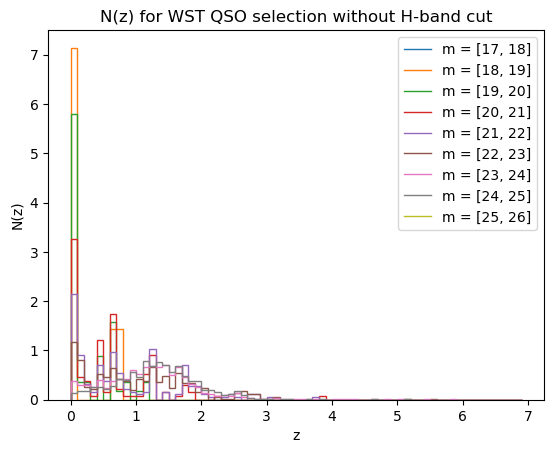

In [103]:
nz_wst_noh = Nz(crossmatched_hsc_cosmos[wst_sel_noh], magbins=mag_bins, zbins=z_bins, outfile='Nz_wst_noh.pkl', mag_col='g', z_col='ZPHOT_NIR', title='N(z) for WST QSO selection without H-band cut')

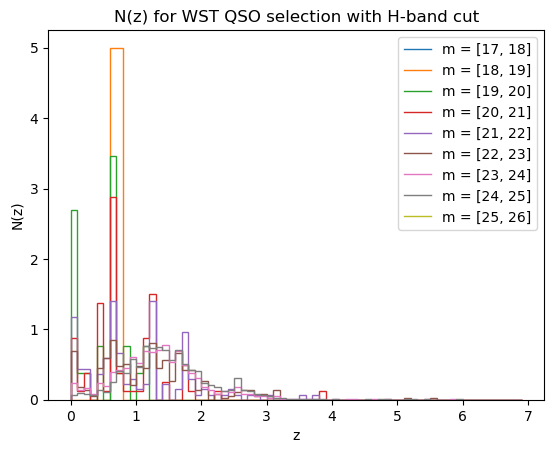

In [104]:
nz_wst_with_h = Nz(crossmatched_hsc_cosmos[wst_sel_with_h], magbins=mag_bins, zbins=z_bins, outfile='Nz_wst_with_h.pkl', mag_col='g', z_col='ZPHOT_NIR', title='N(z) for WST QSO selection with H-band cut')